In [1]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

os.makedirs('../../../doc/assets', exist_ok=True)

/Users/siddharthilayaraja/Documents/Geo-Engine-Terrain-Classifier/.venv/lib/python3.13/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [2]:
# ----- Define Jabalpur District Boundary -----
madhya_pradesh = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
      .filter(ee.Filter.eq('ADM1_NAME', 'Madhya Pradesh'))
      .geometry()
)

# ----- Cloud Masking -----
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

# ----- Sentinel-2 Composite -----
# Extended to full dry season for gap-free coverage over the entire district.
# Scene-level cloud filter relaxed to 50% — per-pixel QA60 masking handles
# individual cloudy pixels, so we just need enough scenes in the collection.
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate('2024-10-01', '2025-05-31')
      .filterBounds(madhya_pradesh)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
      .map(mask_s2_clouds)
)

print('Number of images in collection:', dataset.size().getInfo())

composite = dataset.median().clip(madhya_pradesh)

# ----- Spectral Indices -----
ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
savi = composite.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
    {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
).rename('SAVI')

composite = composite.addBands([ndvi, ndwi, ndbi, savi])
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'SAVI']

Number of images in collection: 4385


/Users/siddharthilayaraja/Documents/Geo-Engine-Terrain-Classifier/.venv/lib/python3.13/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [3]:
# ----- Load Jabalpur Training Points -----
# The forest and soil assets have NO 'label' property in Earth Engine.
# We explicitly set the label on every feature using .map() to guarantee
# all 4 classes survive the sampleRegions + notNull filter.
forest      = ee.FeatureCollection('users/cosypix/jabalpur_forest_points').map(lambda f: f.set('label', 0))
water       = ee.FeatureCollection('users/cosypix/jabalpur_water_points').map(lambda f: f.set('label', 1))
buildings   = ee.FeatureCollection('users/cosypix/jabalpur_urban_points').map(lambda f: f.set('label', 2))
barren      = ee.FeatureCollection('users/cosypix/jabalpur_barren_points').map(lambda f: f.set('label', 3))\n agriculture = ee.FeatureCollection('users/cosypix/jabalpur_agriculture_points').map(lambda f: f.set('label', 4))

class_names = ['Forest', 'Water', 'Buildings', 'Soil']
class_collections = [forest, water, buildings, soil]

print('--- Raw Points per Class ---')
total_points = 0
for name, fc in zip(class_names, class_collections):
    count = fc.size().getInfo()
    total_points += count
    print(f'{name}: {count}')
print(f'Total Points: {total_points}')
print()

all_points = forest.merge(water).merge(buildings).merge(barren).merge(agriculture)

# ----- Sample & Split -----
training = (
    composite.select(bands)
             .sampleRegions(
                 collection=all_points,
                 properties=['label'],
                 scale=10,
                 tileScale=4
             )
             .filter(ee.Filter.notNull(bands + ['label']))
             .randomColumn('random', 42)
)

# ----- Diagnostic: check per-class sample counts after sampling -----
sampled_total = training.size().getInfo()
print(f'--- Sampled Points (after notNull filter): {sampled_total} / {total_points} ---')
for i, name in enumerate(class_names):
    count = training.filter(ee.Filter.eq('label', i)).size().getInfo()
    print(f'{name} (label={i}): {count}')
print()

train_set = training.filter(ee.Filter.lt('random', 0.7))
test_set  = training.filter(ee.Filter.gte('random', 0.7))
print('Train Set Size:', train_set.size().getInfo())
print('Test Set Size:', test_set.size().getInfo())
print()

# ----- Diagnostic: per-class counts WITHIN train_set and test_set -----
# This is the check that actually explains a 0.0000 class-wise accuracy:
# a class can be well represented in `training` overall and still end up
# with zero rows in test_set (or train_set) after the random split,
# especially if its raw point count was small to begin with.
print('--- Per-Class Counts in Train / Test Split ---')
for i, name in enumerate(class_names):
    train_count = train_set.filter(ee.Filter.eq('label', i)).size().getInfo()
    test_count  = test_set.filter(ee.Filter.eq('label', i)).size().getInfo()
    flag = '  <-- MISSING FROM TEST SET' if test_count == 0 else ''
    print(f'{name} (label={i}): train={train_count}, test={test_count}{flag}')
print()

--- Raw Points per Class ---
Forest: 1000
Water: 1000
Buildings: 1000
Soil: 1000
Total Points: 4000

--- Sampled Points (after notNull filter): 4000 / 4000 ---
Forest (label=0): 1000
Water (label=1): 1000
Buildings (label=2): 1000
Soil (label=3): 1000

Train Set Size: 2762
Test Set Size: 1238

--- Per-Class Counts in Train / Test Split ---
Forest (label=0): train=684, test=316
Water (label=1): train=683, test=317
Buildings (label=2): train=675, test=325
Soil (label=3): train=720, test=280



Overall Accuracy: 0.9289176090468497
Kappa Coefficient: 0.90524416952095

--- Confusion Matrix Shape Check ---
Rows: 4 Cols: 4
[[306, 1, 1, 8], [2, 299, 8, 8], [8, 6, 279, 32], [2, 0, 12, 266]]

--- Class-wise Accuracy ---
Forest: Consumer's = 0.9623, Producer's = 0.9684
Water: Consumer's = 0.9771, Producer's = 0.9432
Buildings: Consumer's = 0.9300, Producer's = 0.8585
Soil: Consumer's = 0.8471, Producer's = 0.9500



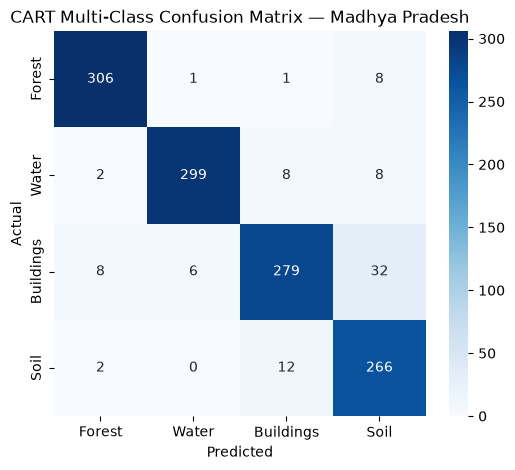

In [4]:
xgb_classifier = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=200,
    shrinkage=0.05,
    maxNodes=5
).train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

# ----- Evaluate on Test Set -----
test_classified = test_set.classify(xgb_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

# --- Matrix shape / sanity check (Step 2) ---
# Confirms the confusion matrix is actually 4x4 and shows the raw
# counts, so a missing/empty row or column is visible directly
# instead of being masked by a misleading 0.0000 accuracy value.
cm_array = confusion_matrix.array().getInfo()
print('\n--- Confusion Matrix Shape Check ---')
print('Rows:', len(cm_array), 'Cols:', len(cm_array[0]) if cm_array else 0)
print(cm_array)

# --- Class-wise Accuracy (Step 3: label-aligned, not position-flattened) ---
# errorMatrix.order() returns the actual label order GEE used to build
# the matrix. Mapping consumers/producers accuracy through this order
# (instead of assuming positions 0,1,2,3 line up with class_names)
# means a genuinely missing class shows up as NaN, not a silent 0.0000.
print('\n--- Class-wise Accuracy ---')
order = confusion_matrix.order().getInfo()
consumers_acc = confusion_matrix.consumersAccuracy().getInfo()
producers_acc = confusion_matrix.producersAccuracy().getInfo()

ca_flat = [item for sublist in consumers_acc for item in sublist]
pa_flat = [item for sublist in producers_acc for item in sublist]

ca_by_label = dict(zip(order, ca_flat))
pa_by_label = dict(zip(order, pa_flat))

for i, name in enumerate(class_names):
    ca = ca_by_label.get(i, float('nan'))
    pa = pa_by_label.get(i, float('nan'))
    print(f"{name}: Consumer's = {ca:.4f}, Producer's = {pa:.4f}")

print()

# ----- Confusion Matrix Heatmap -----
plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CART Multi-Class Confusion Matrix — Madhya Pradesh')
plt.savefig('../../../doc/assets/multi_cart_mp_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# ----- Classify and Visualise -----
classified = composite.select(bands).classify(xgb_classifier)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

class_palette = ['00FF00', '0000FF', 'FF0000', 'D2B48C']

Map = geemap.Map(center=[23.5, 78.5], zoom=6)
Map.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'RGB Composite')
Map.addLayer(classified_smooth, {'min': 0, 'max': 3, 'palette': class_palette}, 'CART Classification')

legend_dict = {
    'Forest (0)':    '00FF00',
    'Water (1)':     '0000FF',
    'Buildings (2)': 'FF0000',
    'Soil (3)':      'D2B48C'
}
Map.add_legend(title='Land Cover', legend_dict=legend_dict)
Map.addLayer(madhya_pradesh, {}, 'Madhya Pradesh Boundary')
Map

Map(center=[23.5, 78.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [6]:
# ----- Class-wise Area Calculation & Export -----
# Because Madhya Pradesh is massive, calculating areas interactively 
# will likely exceed GEE computation limits. We submit a batch task instead.
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=madhya_pradesh,
    scale=30,
    maxPixels=1e13,
    tileScale=16
)

area_feature = ee.Feature(None, areas)
task_area = ee.batch.Export.table.toDrive(
    collection=ee.FeatureCollection([area_feature]),
    description='CART_Multi_MP_Area_Stats',
    fileFormat='CSV'
)
task_area.start()
print('Area calculation batch task started! Please check your Earth Engine Code Editor Tasks tab.')

# Also start a task to export the classification image to Google Drive
task_image = ee.batch.Export.image.toDrive(
    image=classified_smooth,
    description='CART_Multi_MP_Classification',
    folder='GEE_Exports',
    region=madhya_pradesh,
    scale=30,
    maxPixels=1e13
)
task_image.start()
print('Classification Image export batch task started!')


Area calculation batch task started! Please check your Earth Engine Code Editor Tasks tab.
Classification Image export batch task started!
